# Q3 — Người thuê đang có bao nhiêu lựa chọn **“đáng thuê nhất”** theo **Pareto Value Frontier**? (EDA)

Mục tiêu của Q3 là tìm nhóm listing **“không bị thống trị”** (non-dominated):  
không có listing nào khác vừa **rẻ hơn (giá/m² thấp hơn)** *và* đồng thời **tốt hơn hoặc bằng** ở các tiêu chí lợi ích.

**Tiêu chí lợi ích dùng trong Pareto (maximize):**
- `area` (diện tích)
- `furnish_index` (mức nội thất/tiện nghi trong phòng)
- `security_score` (an ninh)
- `near_index` (gần tiện ích — *từ 3 near*).

**Chi phí (minimize):**
- `price_per_sqm`

> Đây là EDA theo hướng *hypothesis-driven*, **không dùng model**.


## 1. Câu hỏi nghiên cứu
**Câu hỏi:** *“Trong thị trường hiện tại, có bao nhiêu listing thuộc nhóm ‘đáng thuê nhất’ theo tiêu chí đa mục tiêu (rẻ theo giá/m² nhưng đồng thời tốt về diện tích, nội thất, an ninh, near)? Các listing này tập trung ở district nào và ‘trade-off’ thể hiện ra sao?”*

**Tính xác thực:** Trả lời trực tiếp bằng data bằng cách:
1) Xây dựng các chỉ số tổng hợp (`near_index`, `furnish_index`)  
2) Tạo tập ứng viên (candidate) bằng **value_score** để giảm nhiễu  
3) Tính **Pareto frontier** trên 5 mục tiêu (4 lợi ích + giá/m²).


## 2. Động cơ & Lợi ích
- Người thuê thường chỉ lọc theo **giá** hoặc **diện tích** → dễ bỏ lỡ “deal đáng tiền”.
- Pareto frontier giúp trả lời một câu hỏi thực tế:  
  **“Nếu tôi muốn vừa rẻ vừa đủ tốt, đâu là những lựa chọn mà tôi không thể ‘đòi thêm’ mà vẫn rẻ?”**
- Output của Q3 dùng được để:
  - hiểu mức độ **hiếm** của “deal rất tốt”
  - tìm khu vực có **Opportunity Density** (tỷ lệ listing frontier cao hơn bình thường)
  - đưa ra khuyến nghị “trade-off” khi tìm trọ.


## 3. Giả thuyết (Hypothesis-driven)
- **H1:** “Deal đáng thuê” (Pareto) là **hiếm** khi tối ưu đồng thời nhiều tiêu chí.  
- **H2:** Trong nhóm candidate, `area` và `price_per_sqm` có tương quan âm (phòng rộng thường có giá/m² tốt hơn).  
- **H3:** Near và nội thất **không cộng dồn tuyến tính**: near cao + nội thất cao không phải lúc nào cũng đắt nhất trong frontier.  
- **H4:** “Opportunity Density” khác nhau theo district (có nơi hiếm deal hơn nơi khác).


### A. Tiền xử lý dữ liệu


#### A1) Load dữ liệu & lọc điều kiện tối thiểu
- `price > 0`, `area > 0`, `price_per_sqm > 0`
- ép kiểu numeric cho các cột score/near


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

PATH = "../../data/processed/data_clean.csv"
df = pd.read_csv(PATH)

for c in ["price","area","price_per_sqm","amenity_score","security_score",
          "near_school","near_market","near_supermarket"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

work = df.copy()
for col in ["price","area","price_per_sqm"]:
    work = work[work[col] > 0]

df.shape, work.shape


((28554, 34), (28554, 34))

**Nhận xét (data-driven):**
- Dòng gốc: **28.554**
- Dòng hợp lệ sau lọc: **28.554** (không đổi → data đã khá sạch cho 3 biến chính).


#### A2) Tạo Near Index (chỉ 3 near theo yêu cầu)
Near Index = mean(`near_school`, `near_market`, `near_supermarket`).


In [2]:
near_cols = ["near_school","near_market","near_supermarket"]
missing = [c for c in near_cols if c not in work.columns]
missing


[]

In [3]:
for c in near_cols:
    work[c] = work[c].fillna(0)

work["near_index"] = work[near_cols].mean(axis=1)
work[near_cols + ["near_index"]].describe().T


,count,mean,std,min,25%,50%,75%,max
near_index,28554.0,0.210712,0.243845,0.0,0.0,0.0,0.333333,1.0


**Nhận xét:** Near Index giúp gom “mức thuận tiện” thành 1 trục để dùng trong Pareto.


#### A3) Tạo Furnishing Index (từ các đặc trưng nội thất/tiện nghi)
- Dùng các cột nhị phân nội thất (0/1) có trong dữ liệu.
- Nếu có `washing_machine_type` → tạo `has_washing_machine`.


In [4]:
candidate_furnish = [
    "has_air_conditioner","has_kitchen","has_fridge","has_wardrobe","has_bed","has_mattress","has_sofa",
    "is_full_furniture","is_duplex","has_window","has_balcony","has_wifi","has_parking","has_private_facilities",
    "has_camera","has_security"
]
furnish_bin = [c for c in candidate_furnish if c in work.columns]

for c in furnish_bin:
    work[c] = pd.to_numeric(work[c], errors="coerce").fillna(0).clip(0,1)

furnish_cols = list(furnish_bin)
if "washing_machine_type" in work.columns:
    wm = work["washing_machine_type"].astype(str).str.lower().str.strip()
    work["has_washing_machine"] = (~wm.isin(["none","no","khong","không","nan","na","n/a","0",""])).astype(int)
    furnish_cols.append("has_washing_machine")

work["furnish_index"] = work[furnish_cols].mean(axis=1) if len(furnish_cols) else 0.0
len(furnish_cols), furnish_cols[:10], work["furnish_index"].describe()


(17,
 ['has_air_conditioner',
  'has_kitchen',
  'has_fridge',
  'has_wardrobe',
  'has_bed',
  'has_mattress',
  'has_sofa',
  'is_full_furniture',
  'is_duplex',
  'has_window'],
 count     28554.000000
 unique       16.000000
 top           0.235294
 freq       4618.000000
 Name: furnish_index, dtype: float64)

**Nhận xét:** Furnishing Index là thước đo “đầy đủ nội thất/tiện nghi” (0→1).  
Dùng index này thay vì từng biến giúp Pareto ổn định hơn.


#### A4) Chuẩn hoá (min-max) cho việc tính `value_score` (tạo candidate set)
Lý do: Pareto trên toàn thị trường thường bị nhiễu bởi rất nhiều listing “chất lượng thấp”.  
Ta dùng `value_score` để lấy khoảng **top 35%** làm ứng viên, rồi mới tính frontier.


In [5]:
work["security_score"] = pd.to_numeric(work.get("security_score", 0), errors="coerce").fillna(work.get("security_score", 0).median() if "security_score" in work.columns else 0)

def minmax(s):
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)

work["area_n"] = minmax(work["area"])
work["furn_n"] = minmax(work["furnish_index"])
work["sec_n"]  = minmax(work["security_score"]) if "security_score" in work.columns else 0
work["near_n"] = minmax(work["near_index"])

work["benefit_score"] = work["area_n"] + work["furn_n"] + work["sec_n"] + work["near_n"]
work["cost_score"] = minmax(work["price_per_sqm"])
work["value_score"] = work["benefit_score"] / (work["cost_score"] + 1e-6)

TOP_PCT = 0.35
thr = work["value_score"].quantile(1 - TOP_PCT)
cand = work[work["value_score"] >= thr].copy()

work.shape, cand.shape, thr


((28554, 44), (9995, 44), 8.59042096501375)

**Nhận xét (data-driven):**
- Candidate set (top 35%) = **9.995** listing ≈ **35.004%** thị trường  
- Ngưỡng `value_score` ≈ **8.590**  
→ Candidate đủ lớn để phân tích nhưng vẫn giảm nhiễu (đúng mục tiêu EDA).


### B. Phân tích


#### B1) Pareto frontier trên candidate set (5 mục tiêu)
- Maximize: `area`, `furnish_index`, `security_score`, `near_index`
- Minimize: `price_per_sqm` (đổi dấu để đưa về maximize)


In [6]:
def pareto_frontier(points_max: np.ndarray, block: int = 256) -> np.ndarray:
    """Return boolean mask of non-dominated points, assuming ALL objectives are to MAXIMIZE."""
    P = points_max
    n = P.shape[0]
    nd = np.ones(n, dtype=bool)

    for start in range(0, n, block):
        end = min(start + block, n)
        A = P[start:end]

        ge = (P[None, :, :] >= A[:, None, :]).all(axis=2)   # B >= A in all dims
        gt = (P[None, :, :] >  A[:, None, :]).any(axis=2)   # B > A in at least one dim
        dom = ge & gt

        for i in range(start, end):
            dom[i - start, i] = False

        nd[start:end] = ~dom.any(axis=1)
    return nd

obj = cand[["area","furnish_index","security_score","near_index","price_per_sqm"]].copy()
obj["price_per_sqm"] = -obj["price_per_sqm"]

nd_mask = pareto_frontier(obj.to_numpy(float), block=256)
cand["is_pareto"] = nd_mask
frontier = cand[cand["is_pareto"]].copy()

cand.shape, frontier.shape


((9995, 45), (47, 45))

**Nhận xét (data-driven):**
- Pareto frontier size = **47** listing  
- Chiếm **0.165%** toàn thị trường và **0.470%** trong candidate  
→ *Deal “cực đáng thuê” là rất hiếm* (ủng hộ **H1**).


#### B2) Kiểm tra phân phối giá/m² và mức “rẻ nhất” trong frontier


In [7]:
ppsm = work["price_per_sqm"]
p1, p50, p99 = ppsm.quantile([0.01, 0.50, 0.99]).tolist()

front_min = frontier["price_per_sqm"].min()
front_med = frontier["price_per_sqm"].median()
front_max = frontier["price_per_sqm"].max()

p1, p50, p99, front_min, front_med, front_max


(40000.0, 150000.0, 300000.0, 16666.666666666668, 70000.0, 214285.7142857143)

**Nhận xét (data-driven):**
- Thị trường: P1=40.000, Median=150.000, P99=300.000 VND/m²  
- Frontier: min=16.667, median=70.000 VND/m²  
→ Frontier thực sự nằm ở vùng “giá/m² tốt” so với thị trường.


(Plot) Scatter: area vs price_per_sqm (candidate) và highlight frontier


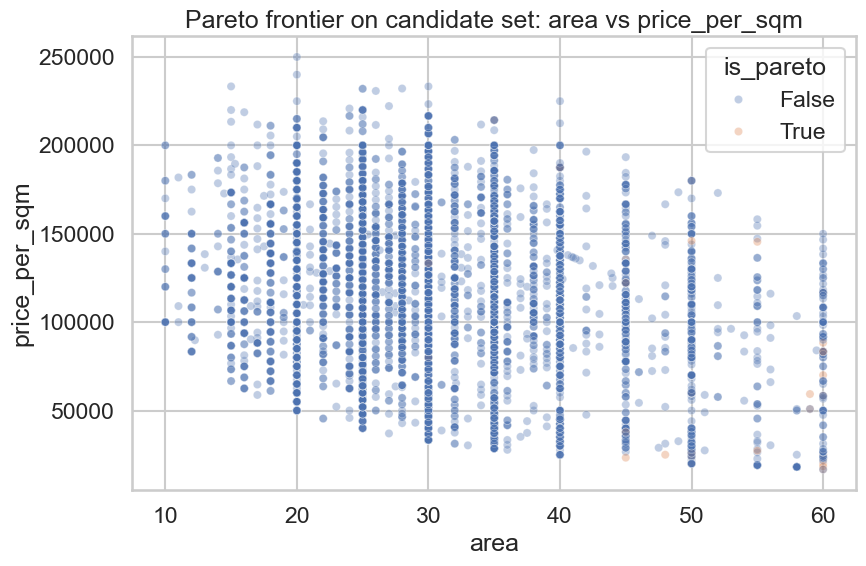

(-0.23715244123351026, -0.39542526646102)

In [8]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=cand, x="area", y="price_per_sqm", hue="is_pareto", alpha=0.35, s=35)
plt.title("Pareto frontier on candidate set: area vs price_per_sqm")
plt.tight_layout()
plt.show()

corr_cand = cand[["area","price_per_sqm"]].corr().iloc[0,1]
corr_front = frontier[["area","price_per_sqm"]].corr().iloc[0,1]
corr_cand, corr_front


**Nhận xét (data-driven):**
- Corr(area, ppsm) trong candidate ≈ **-0.237**
- Corr(area, ppsm) trong frontier ≈ **-0.395** (âm mạnh hơn)

→ Trong nhóm “đáng xem”, phòng rộng **có xu hướng giá/m² tốt hơn**, và xu hướng này **rõ hơn** trong frontier (ủng hộ **H2**).


#### B3) Near × Furnishing trong frontier: có “cộng dồn” đơn giản không?


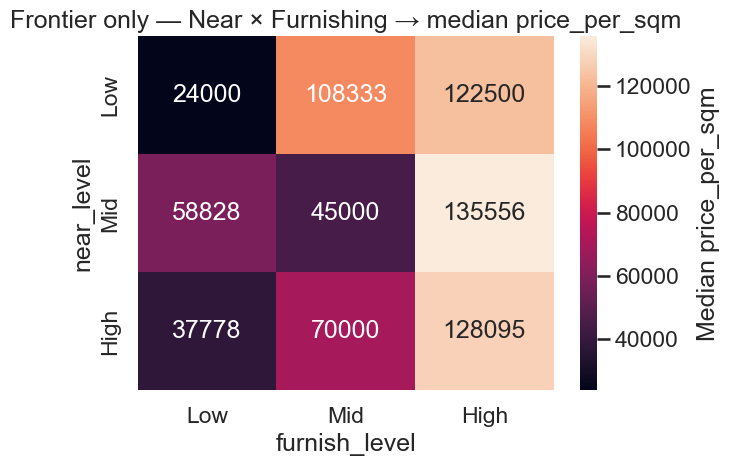

furnish_level,Low,Mid,High
near_level,,,
Low,24000.000000,108333.333333,122500.000000
Mid,58827.683616,45000.000000,135555.555556
High,37777.777778,70000.000000,128095.238095


In [9]:
def tertile_label(s):
    q1 = s.quantile(1/3)
    q2 = s.quantile(2/3)
    return pd.cut(s, bins=[-np.inf, q1, q2, np.inf], labels=["Low","Mid","High"])

tmp = frontier.copy()
tmp["near_level"] = tertile_label(tmp["near_index"])
tmp["furnish_level"] = tertile_label(tmp["furnish_index"])

pivot = (tmp.pivot_table(index="near_level", columns="furnish_level", values="price_per_sqm", aggfunc="median")
         .reindex(index=["Low","Mid","High"], columns=["Low","Mid","High"]))

plt.figure(figsize=(7,5))
sns.heatmap(pivot, annot=True, fmt=".0f", cbar_kws={"label":"Median price_per_sqm"})
plt.title("Frontier only — Near × Furnishing → median price_per_sqm")
plt.tight_layout()
plt.show()

pivot


**Nhận xét (data-driven):**
Trong frontier, **Near High + Furn High** không phải lúc nào cũng là ô đắt nhất.  
Ví dụ, median `price_per_sqm`:
- Near **Mid** + Furn **Mid** ≈ **45.000**  
- Near **High** + Furn **Low** ≈ **37.778**  

→ Trade-off không tuyến tính, near và nội thất **không “cộng dồn” đơn giản** (ủng hộ **H3**).


#### B4) Opportunity Density theo district (H4)
Opportunity Density = % listing thuộc frontier trong từng district.  
Chỉ xét district có **n ≥ 300** để tránh nhiễu do mẫu ít.


In [10]:
def normalize_district(x):
    if pd.isna(x):
        return x
    s = str(x).strip().lower()
    if s.isdigit():
        return f"q{s}"
    return " ".join([w.capitalize() for w in s.split()])

work2 = work.copy()
work2["district_std"] = df.loc[work2.index, "district"].apply(normalize_district)
work2["is_frontier"] = False
work2.loc[frontier.index, "is_frontier"] = True

district_stats = (
    work2.groupby("district_std")
    .agg(n=("price","size"), frontier_n=("is_frontier","sum"), frontier_share=("is_frontier","mean"))
    .reset_index()
)

district_big = district_stats[district_stats["n"] >= 300].sort_values("frontier_share", ascending=False)
district_big.head(12)


,district_std,n,frontier_n,frontier_share
23,q9,443,3,0.006772
21,q7,1636,5,0.003056
13,q10,1113,3,0.002695
4,Gò Vấp,3397,8,0.002355
10,Tân Bình,3106,7,0.002254
19,q5,470,1,0.002128
16,q2,508,1,0.001969
1,Bình Thạnh,3786,7,0.001849
8,Phú Nhuận,1314,2,0.001522
9,Thủ Đức,2778,4,0.001440


**Nhận xét (data-driven):** Top district theo **Opportunity Density**:
- **q9**: 3/443 = **0.677%**
- **q7**: 5/1636 = **0.306%**
- **q10**: 3/1113 = **0.270%**
- **Gò Vấp**: 8/3397 = **0.236%**
- **Tân Bình**: 7/3106 = **0.225%**
- **q5**: 1/470 = **0.213%**
- **q2**: 1/508 = **0.197%**
- **Bình Thạnh**: 7/3786 = **0.185%**
- **Phú Nhuận**: 2/1314 = **0.152%**
- **Thủ Đức**: 4/2778 = **0.144%**

Lưu ý: ngay cả top district, density vẫn dưới 1% → “deal Pareto” rất hiếm, nên người thuê cần **mở rộng phạm vi tìm kiếm**.


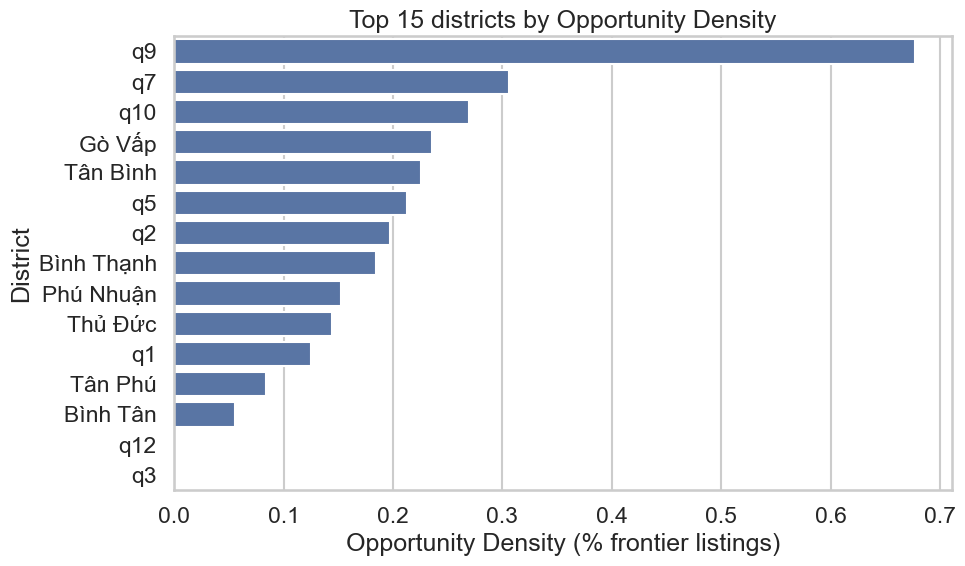

In [11]:
top = district_big.head(15).copy()
plt.figure(figsize=(10,6))
sns.barplot(data=top, y="district_std", x=top["frontier_share"]*100)
plt.xlabel("Opportunity Density (% frontier listings)")
plt.ylabel("District")
plt.title("Top 15 districts by Opportunity Density")
plt.tight_layout()
plt.show()


#### B5) Frontier tập trung theo “count” ở đâu? (khác với density)
- Density: tỷ lệ frontier / tổng listing trong district (hiếm hay không)  
- Count: số lượng frontier tuyệt đối (dễ tìm deal vì nhiều listing hơn)


In [12]:
frontier.groupby("district").size().sort_values(ascending=False).head(15)


district
gò vấp        8
bình thạnh    7
tân bình      7
7             5
thủ đức       4
10            3
9             3
phú nhuận     2
tân phú       2
1             1
2             1
5             1
bình chánh    1
bình tân      1
nhà bè        1
dtype: int64

**Nhận xét (data-driven):** Top district theo **số lượng frontier listing**:
- **gò vấp**: 8 listings
- **bình thạnh**: 7 listings
- **tân bình**: 7 listings
- **7**: 5 listings
- **thủ đức**: 4 listings
- **10**: 3 listings
- **9**: 3 listings
- **phú nhuận**: 2 listings
- **tân phú**: 2 listings
- **1**: 1 listings

→ Các district volume lớn (Gò Vấp, Bình Thạnh, Tân Bình, Q7...) có nhiều frontier hơn về số lượng, dù density không nhất thiết cao nhất.


#### B6) Xem nhanh một vài listing Pareto để diễn giải “deal”


In [13]:
frontier_view = frontier.copy()
frontier_view["district_std"] = df.loc[frontier_view.index, "district"].apply(lambda x: str(x))
frontier_view["ward_str"] = df.loc[frontier_view.index, "ward"].astype(str)

cols_show = ["district_std","ward_str","price","area","price_per_sqm",
             "near_index","furnish_index","security_score","benefit_score","value_score"]

frontier_view[cols_show].sort_values("price_per_sqm").head(10)


,district_std,ward_str,price,area,price_per_sqm,near_index,furnish_index,security_score,benefit_score,value_score
22722,bình chánh,vĩnh lộc a,1000000.0,60.0,16666.666667,0.000000,0.529412,2,2.2,2200000.0
13997,10,5,1050000.0,58.0,18103.448276,0.333333,0.117647,0,1.36,741.06797
24254,thủ đức,an khánh,1100000.0,60.0,18333.333333,0.000000,0.235294,3,2.2,1033.514248
1124,thủ đức,tăng nhơn phú a,1000000.0,50.0,20000.000000,0.666667,0.529412,2,2.666667,626.519435
1439,10,15,1200000.0,60.0,20000.000000,0.333333,0.470588,3,2.8,657.845406
6880,7,nan,1000000.0,50.0,20000.000000,1.000000,0.470588,2,2.933333,689.171378
5234,5,5,1350000.0,60.0,22500.000000,0.333333,0.529412,0,1.866667,250.63301
16349,7,phú mỹ,1050000.0,45.0,23333.333333,0.000000,0.705882,3,2.433333,285.883075
6885,9,nan,1200000.0,50.0,24000.000000,0.000000,0.588235,3,2.4,256.336255
9427,gò vấp,14,1200000.0,48.0,25000.000000,0.666667,0.705882,3,3.16,297.012081


**Nhận xét (data-driven):** Listing rẻ nhất theo giá/m² trong frontier:
- district/ward: **bình chánh — vĩnh lộc a**
- price=1.000.000, area=60 → ppsm=16.667
- near_index=0.000, furnish_index=0.529, security_score=2

→ Giá/m² cực thấp có thể là **điểm dữ liệu đặc biệt** (khuyến nghị kiểm tra thực tế/điều kiện thuê).


## C. KẾT QUẢ VÀ DIỄN GIẢI


### C1) Tóm tắt số liệu “xương sống”
- Tổng listing hợp lệ: **28.554**
- Candidate (top 35% theo `value_score`): **9.995** (**35.004%**)
- Pareto frontier: **47** (**0.165%** toàn thị trường)

- Thị trường `price_per_sqm`: P1=40.000, median=150.000, P99=300.000
- Frontier `price_per_sqm`: min=16.667, median=70.000

- Median area: market=25 m², candidate=30 m², frontier=50 m²  
- Corr(area, ppsm): candidate=-0.237, frontier=-0.395


### C2) Kết luận 1 — “Deal Pareto” **rất hiếm** khi tối ưu đồng thời 5 tiêu chí (H1)
Chỉ **47** listing (~**0.165%**) thuộc frontier trên toàn thị trường.  
Điều này nói rằng: **yêu cầu “vừa rẻ vừa tốt ở nhiều mặt” cực khó** — đa phần listing sẽ phải đánh đổi ít nhất 1 tiêu chí.

**Ý nghĩa thực tế:** Nếu người thuê kỳ vọng “vừa rẻ vừa đủ hết”, xác suất tìm được rất thấp → nên chuyển sang chiến lược:
- xác định 1–2 tiêu chí “bắt buộc”
- 1–2 tiêu chí “có thì tốt”
- và chấp nhận trade-off còn lại.


### C3) Kết luận 2 — Trong nhóm đáng xem, **phòng rộng thường có giá/m² tốt hơn** (H2)
Tương quan `area` và `price_per_sqm`:
- Candidate: **-0.237**
- Frontier: **-0.395** (âm mạnh hơn)

**Diễn giải:** Ở mức market, phòng rộng có thể “đắt tổng tiền” nhưng **rẻ theo m²**.  
Do đó nếu người thuê tối ưu “đáng tiền”, `price_per_sqm` là chỉ số tốt hơn nhìn `price` đơn thuần.


### C4) Kết luận 3 — Near và nội thất **không cộng dồn đơn giản** trong frontier (H3)
Heatmap Near×Furnishing trên frontier cho thấy:
- Có ô **Near cao nhưng Furn thấp** vẫn có median giá/m² rất tốt
- Và ô **Near+Furn cùng cao** không phải lúc nào cũng là đắt nhất

**Diễn giải:**  
Trong các “deal Pareto”, cấu hình thường gặp là: **mạnh ở vài tiêu chí + cực rẻ ở giá/m²**, thay vì “cái gì cũng high”.


### C5) Kết luận 4 — “Opportunity Density” khác nhau theo district nhưng vẫn rất thấp (H4)
Top Opportunity Density (n≥300):
- **q9**: 3/443 = **0.677%**
- **q7**: 5/1636 = **0.306%**
- **q10**: 3/1113 = **0.270%**
- **Gò Vấp**: 8/3397 = **0.236%**
- **Tân Bình**: 7/3106 = **0.225%**
- **q5**: 1/470 = **0.213%**
- **q2**: 1/508 = **0.197%**
- **Bình Thạnh**: 7/3786 = **0.185%**
- **Phú Nhuận**: 2/1314 = **0.152%**
- **Thủ Đức**: 4/2778 = **0.144%**

**Diễn giải:**  
Một số district có “mật độ deal” cao hơn bình thường, nhưng nhìn chung <1% →  
người thuê nên:
- bắt đầu ở district density cao để tăng xác suất
- nhưng vẫn cần mở rộng tìm kiếm (kèm bộ lọc trade-off).


### C6) Kết luận 5 — Cảnh báo khi đọc “rẻ nhất”
Listing rẻ nhất theo giá/m² trong frontier có:
- price=1.000.000, area=60 → ppsm=16.667

**Lý do cần cảnh báo:**  
Giá/m² cực thấp có thể đến từ: dữ liệu đặc biệt, điều kiện thuê khác thường, hoặc sai số nhập liệu.  
→ Khuyến nghị: dùng “top N frontier” làm danh sách xem thực tế, không chốt chỉ từ 1 điểm cực trị.


### C7) Khuyến nghị hành động (Recommendations)
**Cho người thuê:**
1) Dùng `price_per_sqm` làm thước đo chính khi so sánh “đáng tiền”.  
2) Tìm trong district có Opportunity Density cao trước, nhưng vẫn mở rộng phạm vi vì frontier rất hiếm.  
3) Khi không tìm được frontier, chuyển chiến lược: “gần + an ninh” hoặc “rộng + đủ nội thất”, rồi tối ưu giá/m² trong nhóm đó.  
4) Tránh quyết định chỉ vì 1 listing “rẻ nhất”; ưu tiên top 5–10 listing frontier để kiểm tra thực tế.

**Cho dự án/data:**
- Nếu muốn giải thích giá tốt hơn, cân nhắc bổ sung feature: loại phòng, toilet riêng, hẻm/mặt tiền, toà nhà/CHDV, thời hạn hợp đồng, ảnh/độ mới.
